# Pulsar Timing with HENDRICS, Stingray, and PINT

Contact: tuo\<at\>uni-tuebingen.de (youlituo\<at\>gmail.com)

This tutorial shows how to build a synthetic pulsar timing experiment using three tools that are common in high-energy timing analyses:

- **Stingray** provides data structures and utilities for working with event lists and pulse profiles.
- **HENDRICS** adds convenient wrappers for folding and extracting times of arrival (TOAs).
- **PINT** evaluates a timing model against those TOAs and produces timing residuals.

We will simulate photon event times for a slowly spinning down pulsar, recover a set of TOAs from the event data, and compare timing residuals for models with and without a frequency derivative.

## Prerequisites

This notebook assumes you are running **Python ≥ 3.8** in a clean environment
(e.g. a conda env) and have the following packages installed:

```bash
# timing tools
pip install stingray hendrics pint-pulsar tat-pulsar
```

> **Note**  
> - HENDRICS will pull in a compatible version of Stingray, but for this tutorial we
>   assume a reasonably recent Stingray release (≥ 2.2).  
> - `tat-pulsar` is optional and only used in a few convenience functions; you can
>   comment those parts out if you prefer not to install it.


## Preparing the data

To process real-life datasets, you need to download the datasets from the archive, possibly run the L2 pipeline, and barycenter correct them with `barycorr`.

### Download

Use the example scripts to browse the HEASARCH through TAP services:

```bash
$ wget -q -nH -r -l0 -c -N -np -R 'index*' -erobots=off --retr-symlinks --cut-dirs=5 https://heasarc.gsfc.nasa.gov//FTP/ixpe/data/obs/02/02004001/
```

## Barycentric Correction

<img src="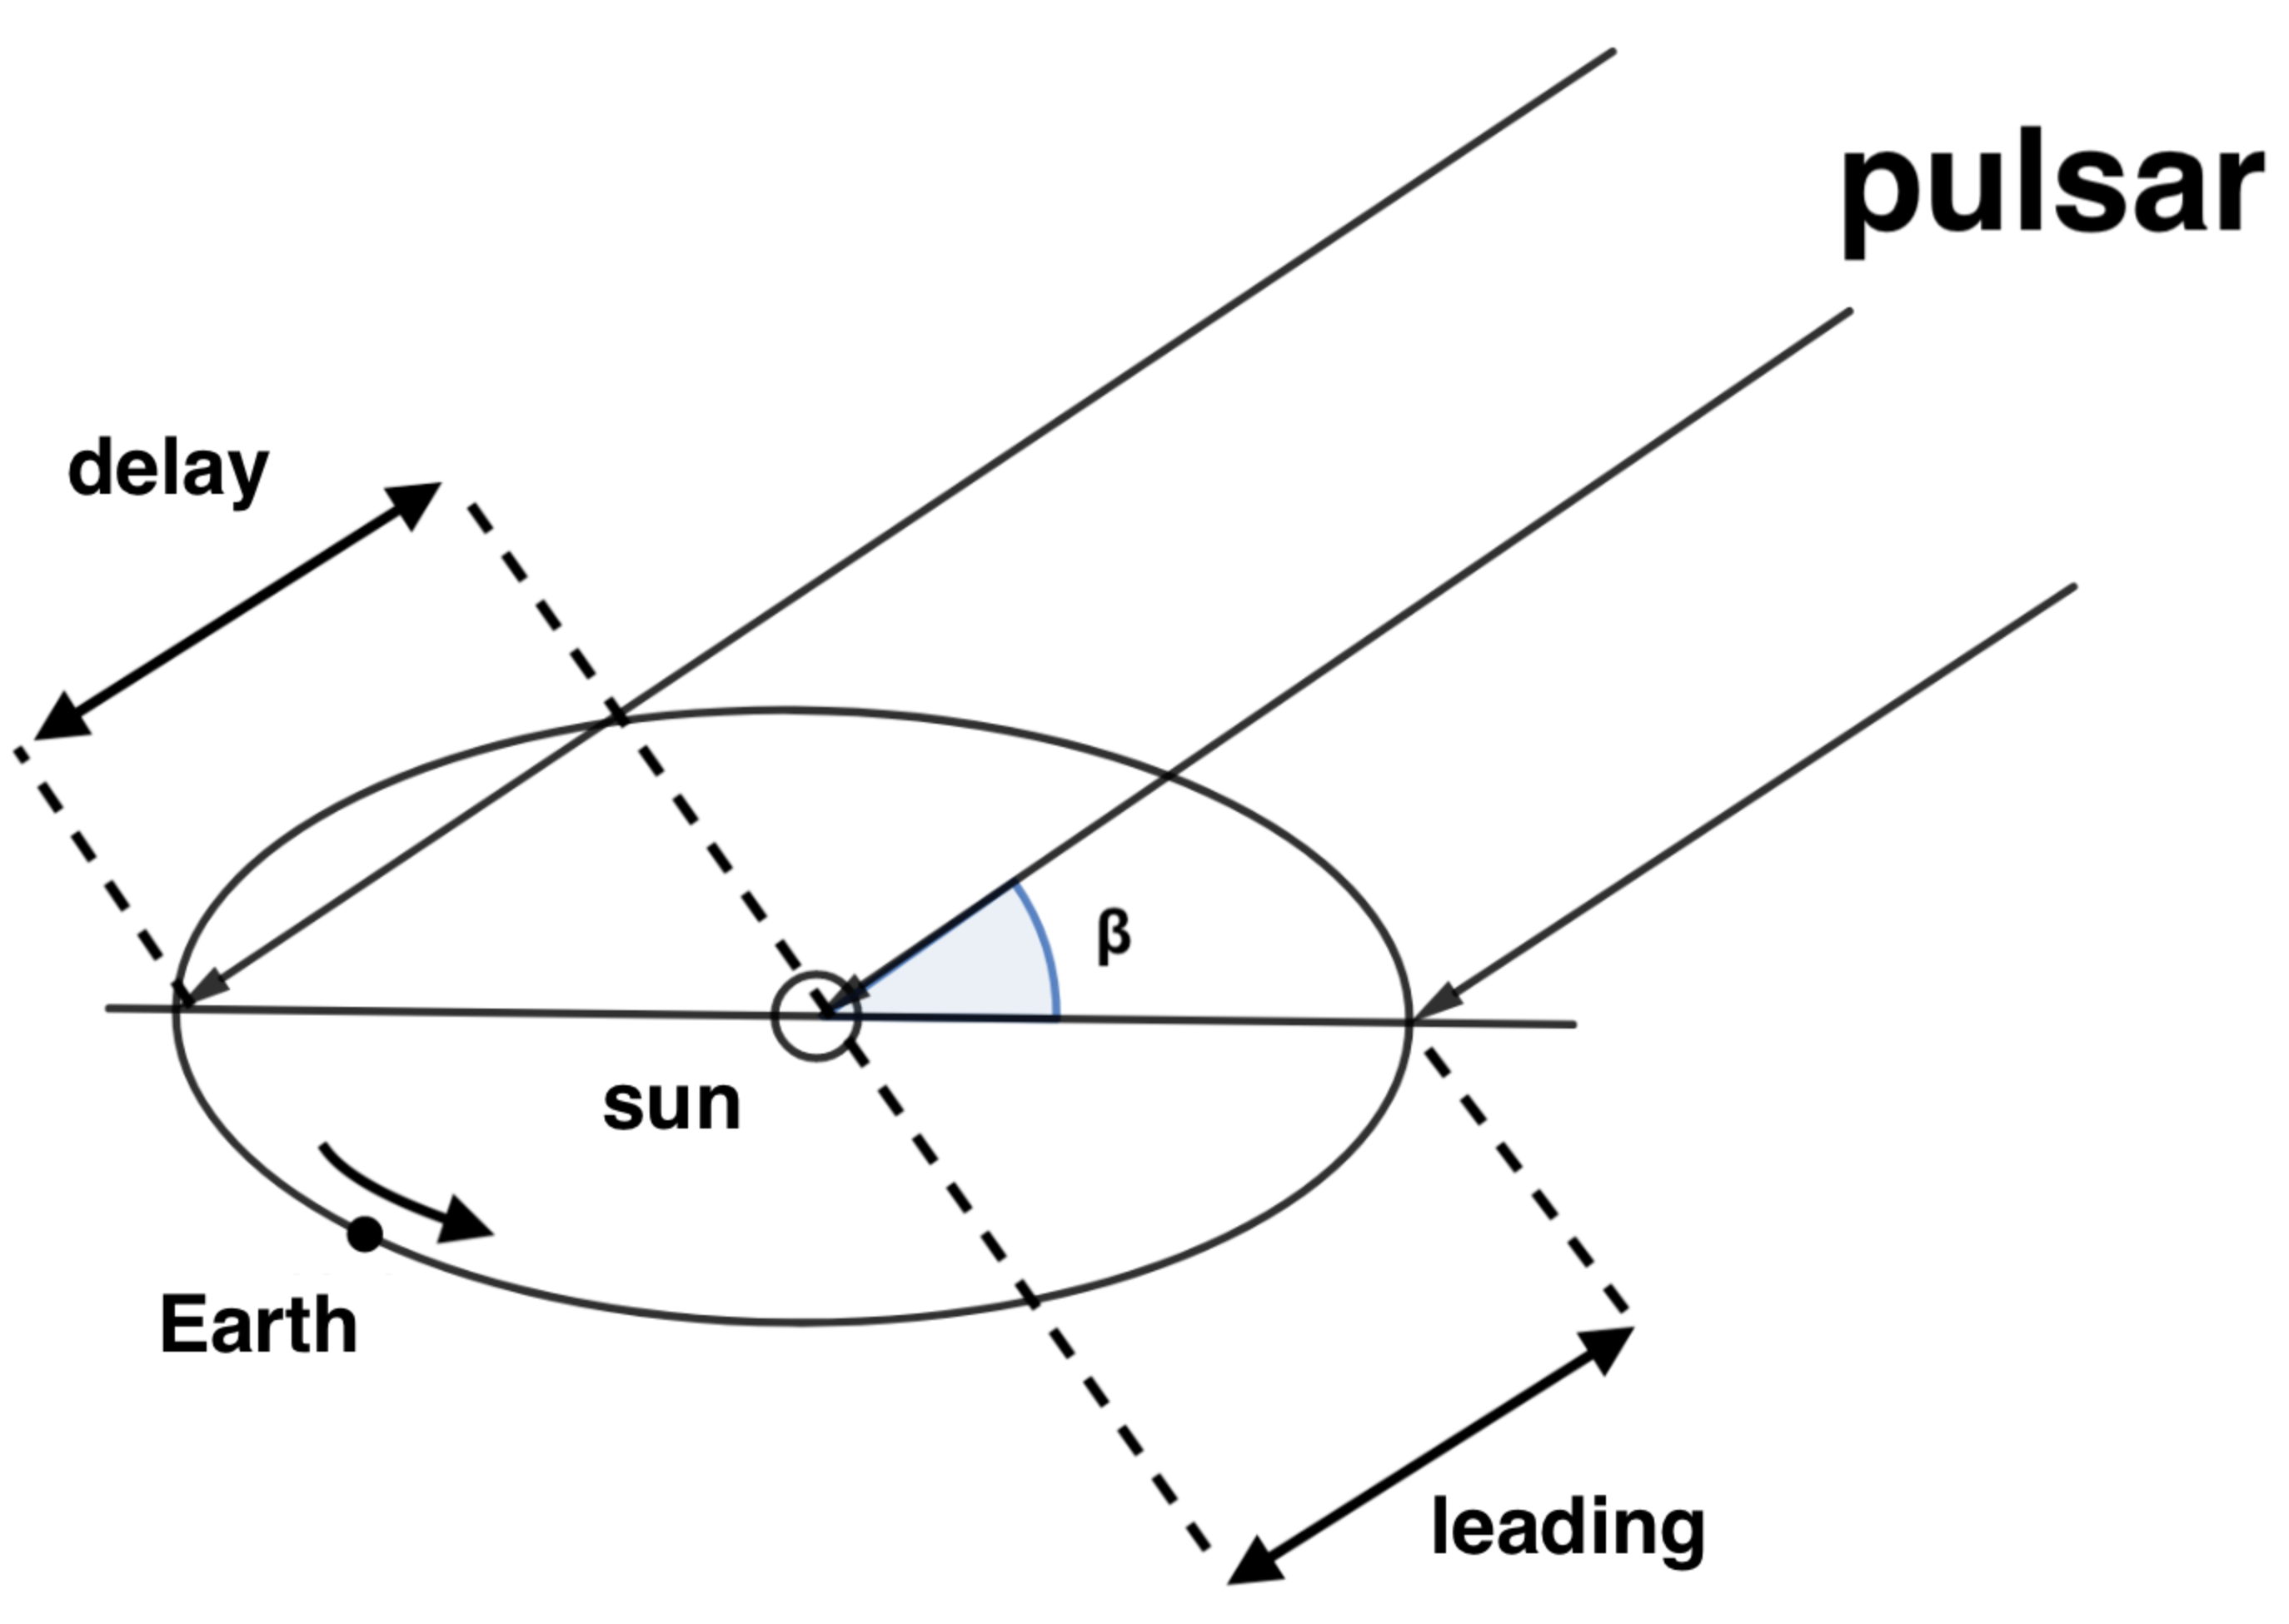
" alt="My plot" width="800"/>
## Understanding the Barycentric Correction

Precise pulsar timing requires that all photon arrival times be measured in a
*common inertial reference frame*. IXPE records event times in the spacecraft
frame, and the spacecraft orbits the Earth, which orbits the Sun. This motion
introduces a varying geometric light-travel delay that must be removed before
we can search for or model pulsations.

### 1. Why barycentric correction is necessary

A pulsar emits pulses at extremely stable intervals in its own rest frame.  
However, as the Earth (and the spacecraft) move around the Sun, we are sometimes
**closer** to the pulsar and sometimes **farther away**. This produces a
geometric delay known as the **Roemer delay**.

In the diagram below:

- The dashed line indicates the fixed direction to the pulsar.
- When the Earth is on the **near side** of its orbit, photons travel a shorter
  path → the pulses arrive earlier (**maximum advance**).
- When the Earth is on the **far side**, the path is longer → the pulses arrive
  later (**maximum delay**).

This modulation has an amplitude of up to  
\\( \pm 500\ \mathrm{s} \times \cos\beta \\),  
where \\( \beta \\) is the ecliptic latitude of the source.

For a pulsar with a spin period of order 1 second (like Her X-1), the uncorrected
arrival times could shift by hundreds of pulses over the course of the
observation.


### Barycentric Correction for IXPE
IXPE often distributes more than one orbit file for a given observation. They need to get listed in a text file, and this text file has to be passed with an @ in front when given to barycorr.

```bash
$ barycorr event_l2/ixpe02004001_det1_evt2_v01.fits.gz ixpe02004001_det1_evt2_v01_bary.fits orbitfiles=@orbit_files ra=254.45754588609 dec=35.34235737652 refframe=ICRS ephem=JPLEPH.430
```
<details>
<summary><b>Click to expand output</b></summary>

```
**** Running barycorr v2.17 ****
: WARNING - input file is .gz gzipped - this may cause problems, especially for large files.
: WARNING - it is recommended to unzip before running this task.
barycorr: shell ftcopy infile='event_l2/ixpe02004001_det1_evt2_v01.fits.gz' outfile='ixpe02004001_det1_evt2_v01_bary.fitsworkfile49668' copyall=YES clobber=YES chatter=0 history=NO
barycorr: running hdaxbary -i '@orbit_files' -f ixpe02004001_det1_evt2_v01_bary.fitsworkfile49668 -jpleph 430 -ra 254.45754588609 -dec 35.34235737652 -ref ICRS
barycorr: shell hdaxbary -i '@orbit_files' -f ixpe02004001_det1_evt2_v01_bary.fitsworkfile49668 -jpleph 430 -ra 254.45754588609 -dec 35.34235737652 -ref ICRS 2>&1
<=== Finished after 3 HDUs
hdaxbary: Using JPL Planetary Ephemeris DE-430
hdaxbary: Using JPL Planetary Ephemeris DE-430
hdaxbary: Using JPL Planetary Ephemeris DE-430barycorr: exited with status 0
barycorr: shell ftchecksum infile='ixpe02004001_det1_evt2_v01_bary.fitsworkfile49668' update=yes datasum=YES chatter=0
barycorr: shell ftcopy infile='ixpe02004001_det1_evt2_v01_bary.fitsworkfile49668' outfile='ixpe02004001_det1_evt2_v01_bary.fits' copyall=YES clobber=YES chatter=0 history=NO
barycorr: barycorr successfully completed

```

</details>

Do the same for all three event lists.
```bash
$ barycorr event_l2/ixpe02004001_det1_evt2_v01.fits.gz ixpe02004001_det1_evt2_v01_bary.fits orbitfiles=@orbit_files ra=254.45754588609 dec=35.34235737652 refframe=ICRS ephem=JPLEPH.430
$ barycorr event_l2/ixpe02004001_det2_evt2_v01.fits.gz ixpe02004001_det2_evt2_v01_bary.fits orbitfiles=@orbit_files ra=254.45754588609 dec=35.34235737652 refframe=ICRS ephem=JPLEPH.430
$ barycorr event_l2/ixpe02004001_det3_evt2_v01.fits.gz ixpe02004001_det3_evt2_v01_bary.fits orbitfiles=@orbit_files ra=254.45754588609 dec=35.34235737652 refframe=ICRS ephem=JPLEPH.430
```

## Source Filtering

Use your favorite tool to create a region file and filter the source events from the background. I use `ds9` for the region and `fselect` for event selection

```bash
 $ for ev in ixpe02004001_det*v01_bary.fits; do fselect $ev ${ev/.fits/_filt.fits} "regfilter('ds9.reg')" clobber=yes; done
 ```

and also select the event files for background region
```bash
$ for ev in ixpe02004001_det*v01_bary.fits; do fselect $ev ${ev/.fits/_bkg.fits} "regfilter('back.reg')" clobber=yes; done
```

In [1]:
!ls -tr 02004001/*fits

02004001/ixpe02004001_det1_evt2_v01_bary.fits
02004001/ixpe02004001_det2_evt2_v01_bary.fits
02004001/ixpe02004001_det3_evt2_v01_bary.fits
02004001/ixpe02004001_det1_evt2_v01_bary_filt.fits
02004001/ixpe02004001_det2_evt2_v01_bary_filt.fits
02004001/ixpe02004001_det3_evt2_v01_bary_filt.fits
02004001/ixpe02004001_det1_evt2_v01_bary_bkg.fits
02004001/ixpe02004001_det2_evt2_v01_bary_bkg.fits
02004001/ixpe02004001_det3_evt2_v01_bary_bkg.fits
02004001/ixpe02004001_det1_evt1_v01_bary.fits
02004001/ixpe02004001_det1_evt1_v01_bary_filt.fits


## Analysis

In [2]:
from stingray import EventList


events1 = EventList.read("02004001/ixpe02004001_det1_evt2_v01_bary_filt.fits", fmt='hea')
events2 = EventList.read("02004001/ixpe02004001_det2_evt2_v01_bary_filt.fits", fmt="hea")
events3 = EventList.read("02004001/ixpe02004001_det3_evt2_v01_bary_filt.fits", fmt="hea")

We can create a single event list from the three. Stingray's time series classes (`EvenList`, `Lightcurve`, etc.) have the join method that can be used to merge together the time series.

In [3]:
events = events1.join(events2)
events = events.join(events3)

/Users/tuoyouli/anaconda3/envs/timing/lib/python3.8/site-packages/stingray/base.py:2026: UserWarning: Attribute instr is different in the time series being merged.
  warnings.warn(
/Users/tuoyouli/anaconda3/envs/timing/lib/python3.8/site-packages/stingray/base.py:2026: UserWarning: Attribute nphot is different in the time series being merged.
  warnings.warn(


<Axes: xlabel='Time (s)', ylabel='counts'>

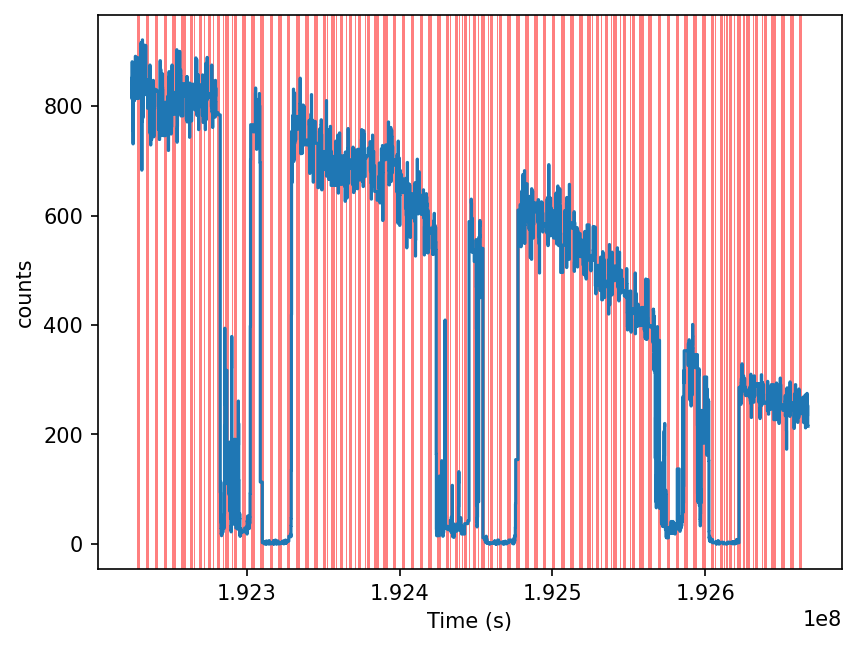

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150


lc = events.to_lc(dt=100)

# This is just to clean up the light curve from all points outside the GTIs, for plotting purposes.
lc.apply_gtis(inplace=True)
lc.plot()

## Binary-Orbit Correction

After applying the barycentric correction, the photon arrival times are already
referenced to the Solar System Barycentre (SSB). However, for **binary pulsars**
like **Her X-1**, the neutron star is itself orbiting its companion. This motion
adds an additional delay that must be removed before we search for or model the
spin period.

### 1. Why binary correction is needed

In a binary system, the pulsar moves around the system’s center of mass.  
As it moves:

- When the pulsar is **closer** to us (approaching), the light-travel time is
  shorter → pulses arrive **earlier**.
- When the pulsar is **farther** (receding), the travel time is longer → pulses
  arrive **later**.

This additional delay is called the **Roemer delay** of the binary orbit.

For Her X-1 (https://gammaray.nsstc.nasa.gov/gbm/science/pulsars/lightcurves/herx1.html):

<img src="data:image/png;base64, ..." alt="My plot" width="800"/>

- Orbital period  
  $ P_b \approx 1.7001674\ \text{days} $
- Projected semi-major axis  
  $ x = a_1 \sin i / c = 13.185\ \text{light-seconds} $
- Eccentricity  
  $ e \approx 0 $ (nearly circular)
- Long-term period derivative  
  $ \dot{P}_b = -4.93 \times 10^{-11}\ \text{days/day} $

Because the orbit is nearly circular, the timing modulation is very close to a
clean sinusoid with amplitude **~13 seconds**. If this effect is not removed,
the pulsar phases drift rapidly and the 1.24-second pulse signal becomes
smeared over the orbit.

### 2. What the binary correction computes

For each photon, we compute the difference between the emission time at the
pulsar and the arrival time at the SSB:

$$
\Delta t_{\mathrm{bin}}(t) = \frac{a_1 \sin i}{c}
\sin \left( \frac{2\pi}{P_b}(t - T_0) \right),
$$

in the circular orbit approximation.

In the general case (including eccentricity, periastron advance, or
Einstein/Shapiro delays), the full binary model solves **Kepler’s equation**
and evaluates the full BT/ELL1 timing delay. The function
`tatpulsar.pulse.binarycor.Cor()` implements this general binary delay model.



In [5]:
from tatpulsar.pulse.binarycor import Cor
from tatpulsar.utils.functions import met2mjd, mjd2met
import numpy as np

pb = 1.7001674 * 86400 
pb_dot = -4.93e-11
x  = 13.185            # a1 * sin i / c = 1 light-second
e  = 0.0           # eccentricity
t0 = 2449420.67347 - 2400000.5           # periastron time
omega = 0.0        # rad

tw = t0 - 1.7001674/4

t_corr = np.empty_like(events.time)
for i in range(len(events.time)):
    t_corr[i] = Cor(met2mjd(events.time[i], 'ixpe'),
                    tw, e, pb, pb_dot, omega, 0, x, 0)
t_em = events.time + t_corr

/Users/tuoyouli/anaconda3/envs/timing/lib/python3.8/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


## Pulsation search

Once we have barycentric- and binary-corrected event times, the main goal of
timing analysis is to detect and measure **periodic signals** from the pulsar.
A pulsation search asks:

> “Is there a coherent periodicity in these photon arrival times, and if so,
> at what frequency (or period)?”

There are several families of tests for this, such as Fourier power spectra,
epoch-folding statistics, and phase-based tests. One very widely used
phase-based test in high-energy astronomy is the **Z-squared (Z²) statistic**
(Buccheri et al. 1983).

### The Z-squared statistic

The Z-squared test works directly on the **phases** of the photons at a *trial*
signal frequency. For each trial frequency \( $\nu$ \), we compute the phase of
each photon:

$$
\phi_j = \nu t_j \quad (\mathrm{mod}\ 1),
$$

where \( $t_j$ \) is the (corrected) arrival time of photon \( $j$ \). If there is
no pulsation at that frequency, the phases \( $\phi_j$ \) should be uniformly
distributed in \([0, 1)\). If a pulsation is present, the phases will tend
to cluster, and this can be detected through sinusoidal moments.

For \( $N$ \) photons and a chosen number of harmonics \( $n$ \), the
\( $Z_n^2$ \) statistic is defined as

$$
Z_n^2
= \frac{2}{N} \sum_{k=1}^{n}
\left[
\left(\sum_{j=1}^{N} \cos k\phi_j \right)^2
+
\left(\sum_{j=1}^{N} \sin k\phi_j \right)^2
\right].
$$

- \( N \) is the number of photons.  
- \( n \) is the number of harmonics included in the test  
  (e.g. \(n = 1\) for a nearly sinusoidal pulse profile, higher \(n\) for
  more complex profiles).  
- \( $\phi_j$ \) are the phases of the events at the trial frequency.

If the phases are purely random (no pulsation), \( $Z_n^2$ \) follows a
chi-square distribution with \( $2n$ \) degrees of freedom. A strong periodic
signal produces a **large excess** in \( $Z_n^2$ \) at the true spin frequency
(and often at its harmonics).

In **Stingray**, the Z-squared search is implemented in
`stingray.pulse.search.z_n_search`, which scans a frequency grid and computes
\( $Z_n^2$ \) at each trial frequency.


In [6]:
import numpy as np
from stingray.pulse.search import epoch_folding_search, z_n_search

period = 1/0.807947352321026
nbin = 32
obs_length = events.time.max() - events.time.min()
df_min = 1/obs_length
oversampling = 35
df = df_min / oversampling
frequencies = np.arange(1/period - 200 * df, 1/period + 200 * df, df)

nharm = 2
freq, zstat = z_n_search(t_em, frequencies, nbin=nbin, nharm=nharm)


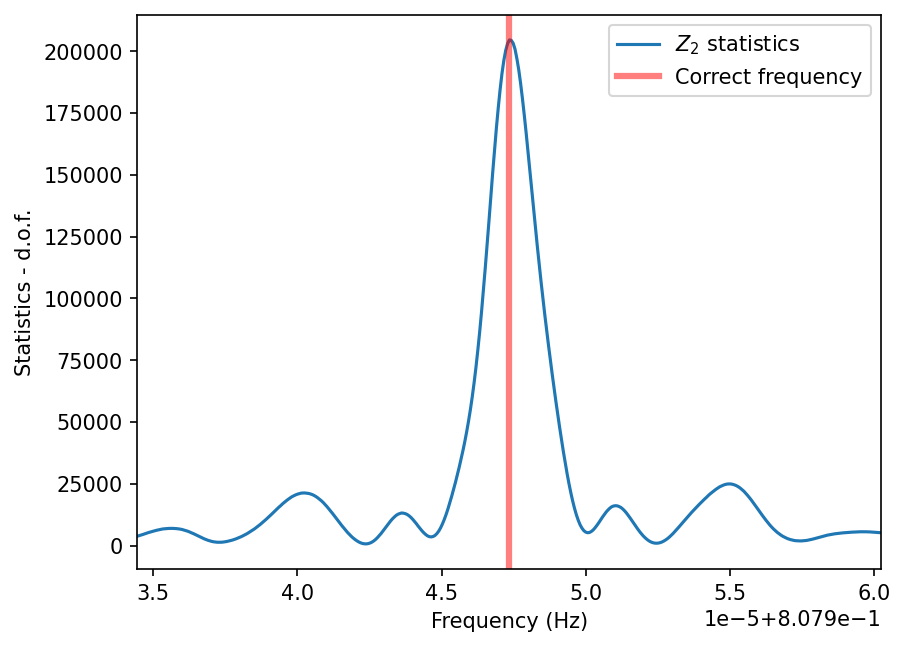

In [50]:
# ---- PLOTTING --------
plt.figure()
plt.plot(freq, (zstat - nharm), label='$Z_2$ statistics')

plt.axvline(1/period, color='r', lw=3, alpha=0.5, label='Correct frequency')
plt.xlim([frequencies[0], frequencies[-1]])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Statistics - d.o.f.')
plt.legend()


In [43]:
period_best = 1/freq[np.argmax(zstat)]

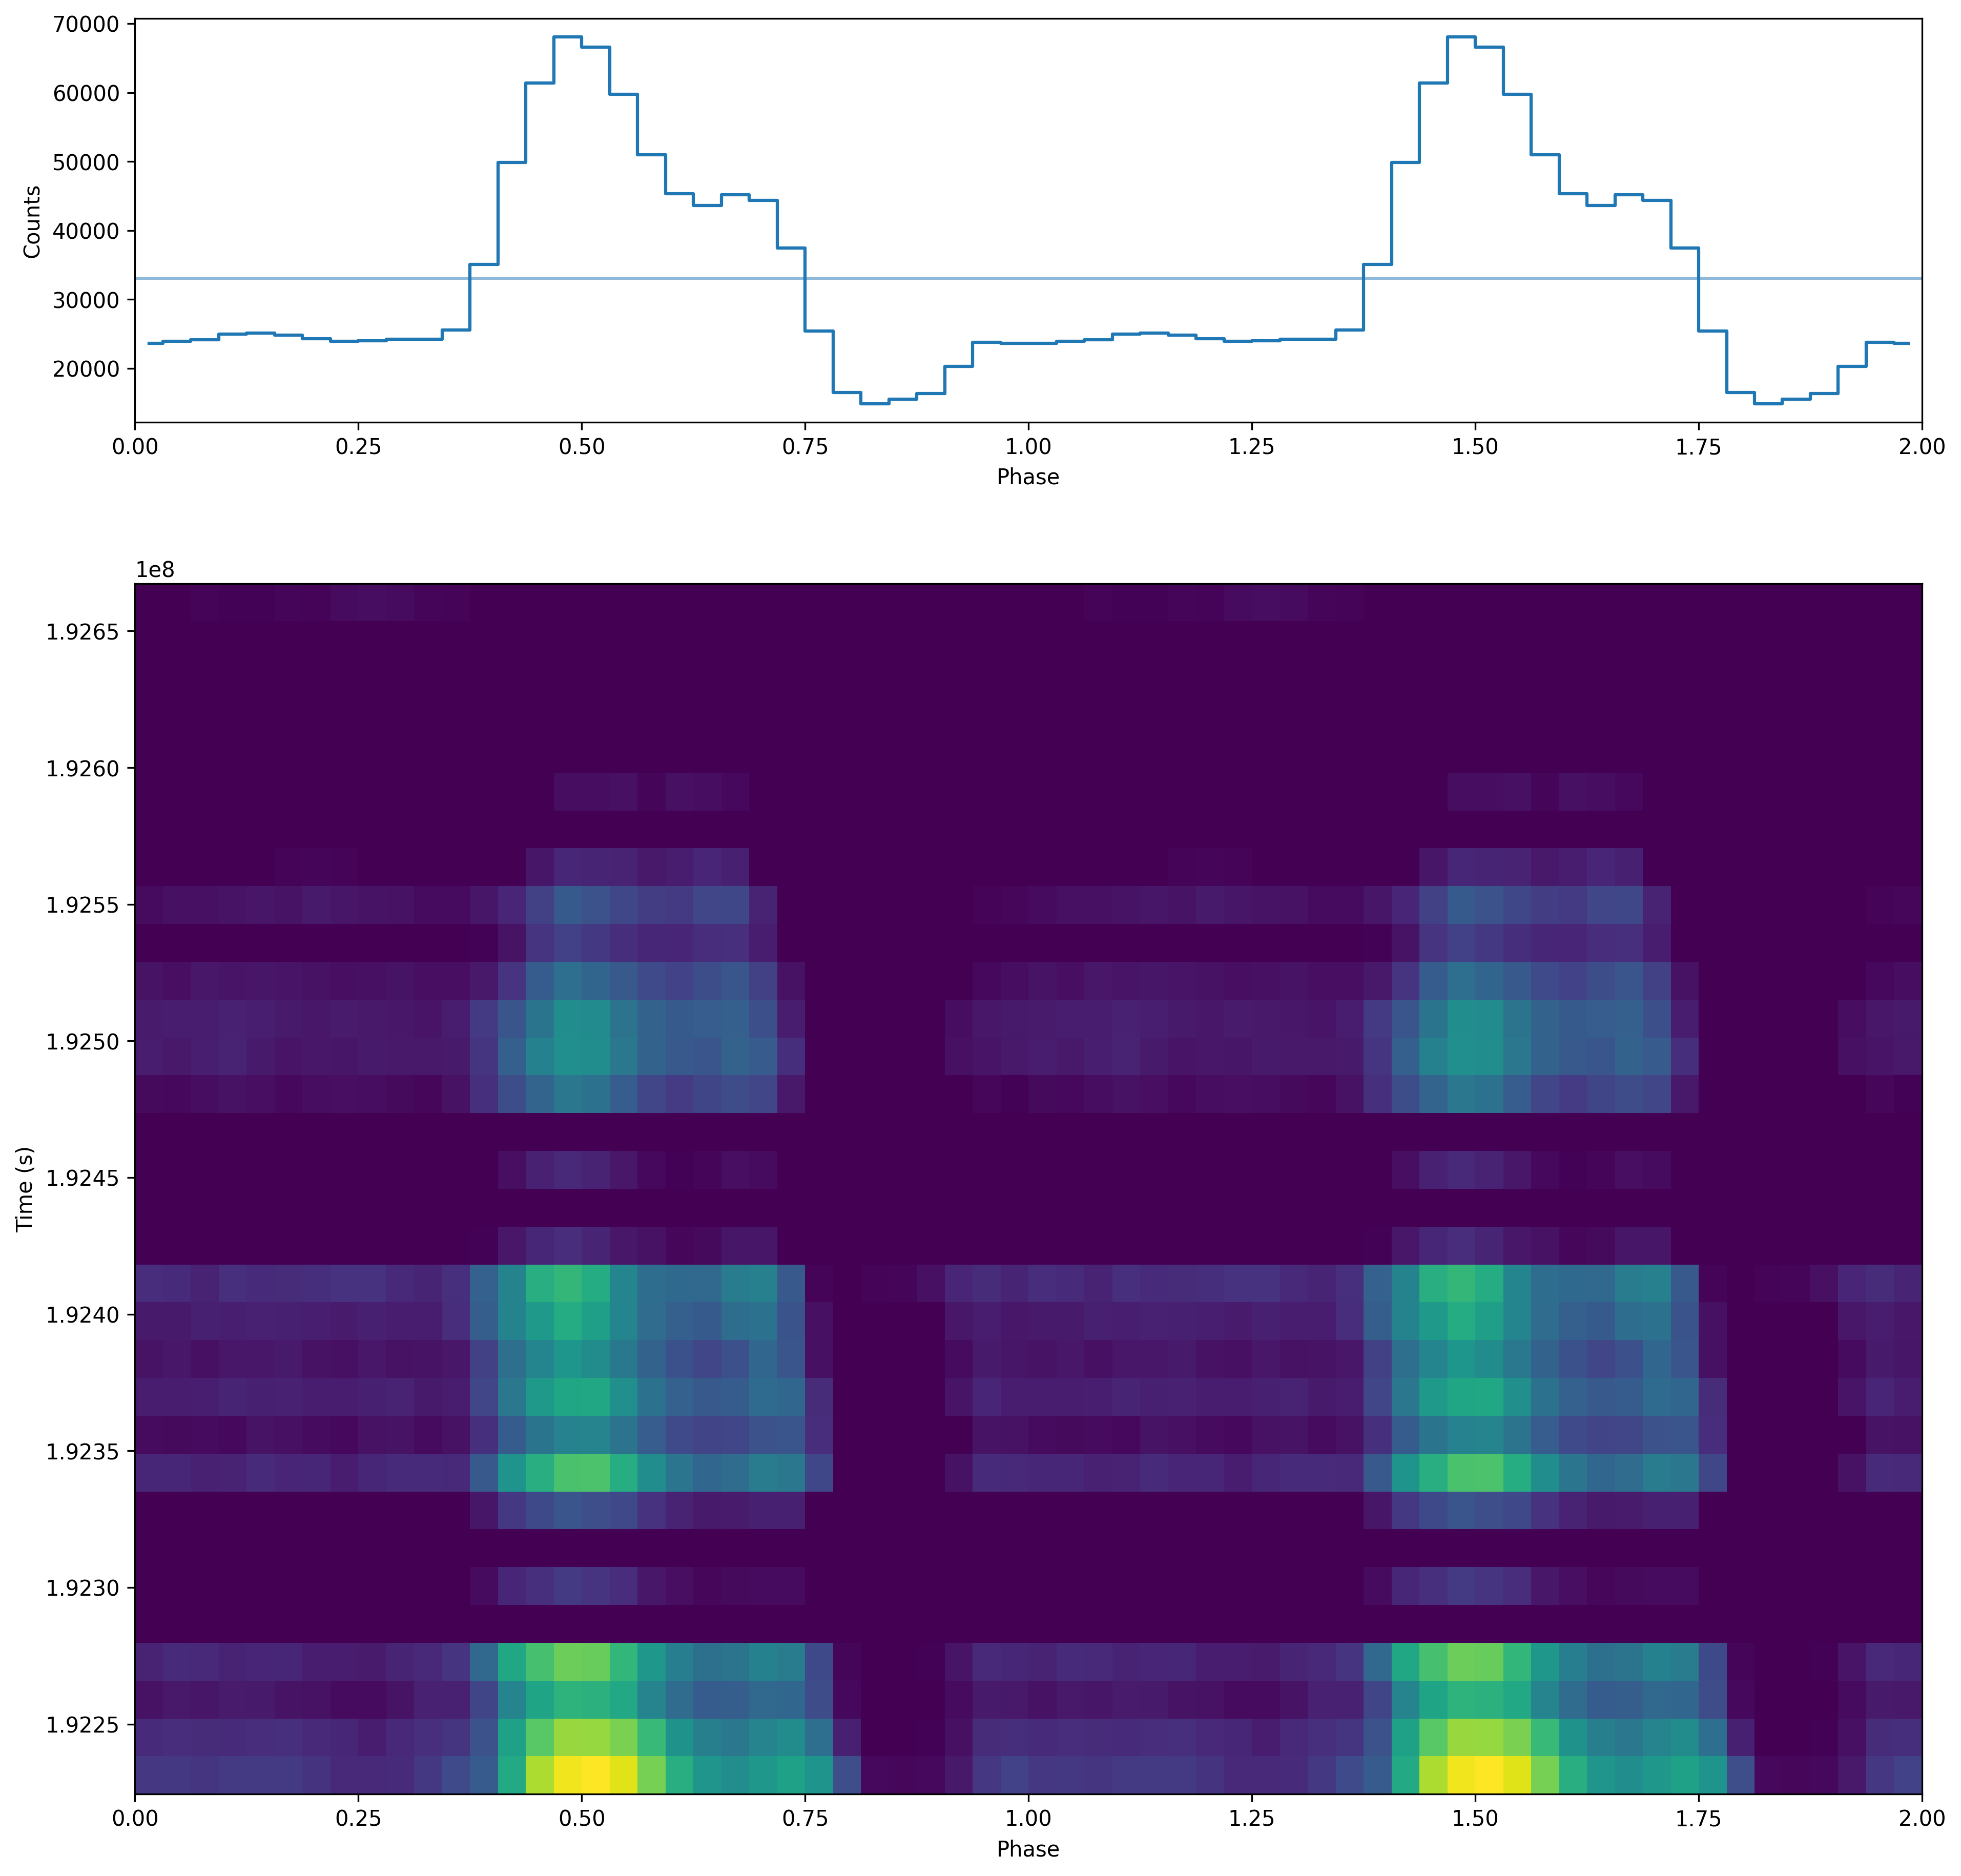

In [44]:
from stingray.pulse.search import phaseogram, plot_phaseogram, plot_profile
from matplotlib.gridspec import GridSpec

# Calculate the phaseogram
phaseogr, phases, times, additional_info = \
            phaseogram(t_em, 1/period_best, return_plot=True, nph=nbin, nt=32)

# ---- PLOTTING --------

# Plot on a grid
plt.figure(figsize=(15, 15))
gs = GridSpec(2, 1, height_ratios=(1, 3))
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1], sharex=ax0)

mean_phases = (phases[:-1] + phases[1:]) / 2
plot_profile(mean_phases, np.sum(phaseogr, axis=1), ax=ax0)
# Note that we can pass arguments to plt.pcolormesh, in this case vmin
_ = plot_phaseogram(phaseogr, phases, times, ax=ax1, vmin=np.median(phaseogr))